In [74]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

In [75]:
load_dotenv()

True

In [76]:
class SubState(TypedDict):

    input_text: str
    translated_text: str

In [77]:
subgraph_llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

In [78]:
def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

In [79]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [80]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str
    

In [81]:
parent_llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

In [82]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [83]:
def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}

In [84]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

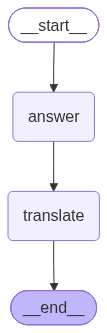

In [85]:
graph = parent_builder.compile()

graph

In [86]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': [{'type': 'text',
   'text': '**Quantum physics** (also known as quantum mechanics) is the branch of science that studies the fundamental building blocks of nature at the smallest scales—specifically at the level of atoms and subatomic particles (like electrons and photons).\n\nWhile classical physics (Newton\'s laws) explains how large things work—like falling apples, orbiting planets, and speeding cars—it fails when applied to the microscopic world. Quantum physics steps in to explain how the universe works at a microscopic level, and it turns out to be very strange and counterintuitive.\n\nHere are a few key concepts that define quantum physics:\n\n1. **Quantization (Energy Packets):** \n   In our everyday world, energy seems to flow continuously (like water from a hose). In the quantum world, energy comes in discrete, indivisible packets called **quanta** (singular: *quantum*). Think of it like walking up a staircase rather tha